# Block 17 — U.S. Equity Factor Rotation and Combined Sector–Factor Allocation
## Corrected Pine-Parity Implementation

This corrected Block 17 replaces the preliminary state-machine reconstruction with the **exact frozen Block 3 + Block 4 architecture**.

The economic experiment is unchanged:

- factor-only rotation;
- combined 50% sector / 50% factor strategic sleeve;
- long-only;
- fully invested;
- no leverage;
- no shorting;
- no VIX/correlation overlay;
- no parameter optimization.

## Correction

The preliminary Block 17 simplified parts of the proprietary Pine state machine. This version restores:

- one-shot `earlyReversalSawBelowBB` memory;
- one-shot `pullbackSawAboveBB` memory;
- exact entry priority: early reversal > pullback > profit taking;
- exact early-reversal exit modes;
- exact pullback exit rules;
- exact profit-taking persistence;
- exact strategic `positionHeld` logic;
- portfolio-effective tactical-state separation;
- the frozen Block 4 active-weight staircase.

It also restores the canonical **Friday signal → next U.S. trading-session execution → execution-close-to-next-execution-close return** convention.

A sector parity audit compares the reconstructed sector signal/state engine with the frozen Block 3 / Block 4 outputs before the factor-extension results are accepted.


In [1]:
# ============================================================
# BLOCK 17.1 — ENVIRONMENT, PATHS & FROZEN SPECIFICATION
# ============================================================

from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import yfinance as yf
except ImportError:
    !pip -q install yfinance
    import yfinance as yf

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

PROJECT_ROOT = Path(
    r"/content/drive/My Drive/Colab Notebooks/Sector Rotation Model/"
    r"State-Dependent U.S. Equity Sector Rotation - "
    r"A Systematic Framework for Trend-Based Active Sector Allocation"
)
if not PROJECT_ROOT.exists():
    alt = Path(str(PROJECT_ROOT).replace("/My Drive/", "/MyDrive/"))
    if alt.exists():
        PROJECT_ROOT = alt
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(PROJECT_ROOT)

OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MANIFEST_DIR = PROJECT_ROOT / "manifests"
for p in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, MANIFEST_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SECTORS = ["XLC","XLY","XLP","XLE","XLF","XLV","XLI","XLK","XLB","XLRE","XLU"]
FACTORS = ["MTUM","QUAL","VLUE","SIZE","USMV"]
ALL_ASSETS = SECTORS + FACTORS
BENCHMARK = "SPY"

PARAMS = {
    "smoothing_length": 5,
    "fast_ma_length": 20,
    "slow_ma_length": 50,
    "signal_line_length": 25,
    "direction_lookback": 2,
    "bb_volatility_lookback": 20,
    "bb_volatility_smoothing": 5,
    "upper_bb_multiplier": 1.0,
    "lower_bb_multiplier": 1.0,
    "strategic_vol_lookback": 52,
    "tsmom_lookback": 52,
    "tsmom_tilt": 0.25,
    "active_min": -0.50,
    "active_max": 0.50,
    "active_step": 0.10,
}
PPY = 52

print("Project root:", PROJECT_ROOT)
print("Factor universe:", FACTORS)
print("Combined assets:", len(ALL_ASSETS))


Mounted at /content/drive
Project root: /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation
Factor universe: ['MTUM', 'QUAL', 'VLUE', 'SIZE', 'USMV']
Combined assets: 16


In [2]:
# ============================================================
# BLOCK 17.2 — LOAD CANONICAL SECTOR DATA, CALENDAR & PARITY REFERENCES
# ============================================================

def load_manifest(name):
    p = MANIFEST_DIR / name
    if not p.exists():
        raise FileNotFoundError(p)
    with open(p, "r", encoding="utf-8") as f:
        return json.load(f)

def resolve_existing(value):
    p = Path(value)
    if p.exists():
        return p
    hits = list(PROJECT_ROOT.rglob(p.name))
    if hits:
        return hits[0]
    raise FileNotFoundError(p)

def resolve_manifest_file(mapping, preferred_keys, tokens, label):
    for k in preferred_keys:
        if k in mapping:
            try:
                p = resolve_existing(mapping[k])
                print(label, ":", p)
                return p
            except Exception:
                pass
    for k, v in mapping.items():
        if isinstance(v, str):
            n = Path(v).name.lower()
            if all(t.lower() in n for t in tokens):
                try:
                    p = resolve_existing(v)
                    print(label, ":", p)
                    return p
                except Exception:
                    pass
    raise FileNotFoundError(f"Could not resolve {label}. Keys={list(mapping)}")

block2 = load_manifest("block_2_universe_data_weights.json")
block3 = load_manifest("block_3_signal_engine.json")
block4 = load_manifest("block_4_state_active_weights.json")

saved2 = block2["saved_files"]
saved3 = block3["saved_files"]
saved4 = block4["saved_files"]

CALENDAR_PATH = resolve_manifest_file(
    saved2,
    ["weekly_signal_execution_calendar", "signal_execution_calendar"],
    ["signal", "execution", "calendar"],
    "Calendar",
)
DAILY_CLOSE_PATH = resolve_manifest_file(
    saved2,
    ["daily_adjusted_close", "daily_close", "adjusted_close_daily"],
    ["daily", "close"],
    "Daily adjusted close",
)
BLOCK3_SIGNAL_PATH = resolve_manifest_file(
    saved3,
    ["signal_engine_long", "signal_long"],
    ["signal", "engine", "long"],
    "Frozen Block 3 signal engine",
)
BLOCK4_STATE_PATH = resolve_manifest_file(
    saved4,
    ["state_signal_long", "state_long", "weekly_state_dependent_state_long"],
    ["state", "long"],
    "Frozen Block 4 state history",
)
BLOCK4_ACTIVE_PATH = resolve_manifest_file(
    saved4,
    ["canonical_active_weights_long", "active_weights_long"],
    ["active", "weight", "long"],
    "Frozen Block 4 active multipliers",
)

calendar = pd.read_parquet(CALENDAR_PATH).copy()
sector_daily = pd.read_parquet(DAILY_CLOSE_PATH).copy()
block3_sector = pd.read_parquet(BLOCK3_SIGNAL_PATH).copy()
block4_sector_state = pd.read_parquet(BLOCK4_STATE_PATH).copy()
block4_sector_active = pd.read_parquet(BLOCK4_ACTIVE_PATH).copy()

sector_daily.index = pd.to_datetime(sector_daily.index).tz_localize(None)
sector_daily = sector_daily[
    SECTORS + ([BENCHMARK] if BENCHMARK in sector_daily.columns else [])
]

for df in [block3_sector, block4_sector_state, block4_sector_active]:
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None)

calendar.index = pd.to_datetime(calendar.index).tz_localize(None)
if "execution_date" in calendar.columns:
    calendar["execution_date"] = pd.to_datetime(
        calendar["execution_date"]
    ).dt.tz_localize(None)

print("Sector daily range:", sector_daily.index.min(), "to", sector_daily.index.max())
print("Frozen Block 3 rows:", len(block3_sector))
print("Frozen Block 4 state rows:", len(block4_sector_state))


Calendar : /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/data/processed/weekly_signal_execution_calendar.parquet
Daily adjusted close : /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/data/processed/daily_adjusted_close_12_assets.parquet
Frozen Block 3 signal engine : /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/data/processed/weekly_sector_signal_engine_long.parquet
Frozen Block 4 state history : /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/data/processed/weekly_state_dependent_state_long.p

In [3]:
# ============================================================
# BLOCK 17.3 — DOWNLOAD FACTOR ETF DATA
# ============================================================

download_start = min(sector_daily.index.min(), pd.Timestamp("2011-01-01"))
download_end = pd.Timestamp.today().normalize() + pd.Timedelta(days=2)

raw = yf.download(
    FACTORS,
    start=download_start.strftime("%Y-%m-%d"),
    end=download_end.strftime("%Y-%m-%d"),
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True,
)

if isinstance(raw.columns, pd.MultiIndex):
    factor_daily = raw["Close"].copy()
else:
    factor_daily = raw[["Close"]].rename(columns={"Close": FACTORS[0]})

factor_daily.index = pd.to_datetime(factor_daily.index).tz_localize(None)
factor_daily = factor_daily.reindex(columns=FACTORS).sort_index()

coverage = pd.DataFrame({
    "First_Valid": factor_daily.apply(lambda s: s.first_valid_index()),
    "Last_Valid": factor_daily.apply(lambda s: s.last_valid_index()),
    "Observations": factor_daily.notna().sum(),
})
display(coverage)

if factor_daily[FACTORS].notna().sum().min() < 100:
    raise ValueError("Insufficient factor ETF history downloaded.")


,First_Valid,Last_Valid,Observations
Ticker,,,
MTUM,2013-04-18,2026-08-28,3362
QUAL,2013-07-18,2026-08-28,3299
VLUE,2013-04-18,2026-08-28,3362
SIZE,2013-04-18,2026-08-28,3362
USMV,2011-10-20,2026-08-28,3735


In [4]:
# ============================================================
# BLOCK 17.4 — BUILD WEEKLY FRIDAY-LABELLED DATA
# ============================================================

daily = sector_daily.join(factor_daily, how="inner")
daily = daily.sort_index()

weekly = daily.resample("W-FRI").last()

# Require all 16 investable ETFs for the combined test.
weekly_assets = weekly[ALL_ASSETS].dropna()

# SPY may already be in Block 2; otherwise download it.
if BENCHMARK not in weekly.columns:
    spy_raw = yf.download(
        BENCHMARK,
        start=daily.index.min().strftime("%Y-%m-%d"),
        end=download_end.strftime("%Y-%m-%d"),
        auto_adjust=True,
        progress=False,
    )
    spy_close = spy_raw["Close"]
    if isinstance(spy_close, pd.DataFrame):
        spy_close = spy_close.iloc[:, 0]
    spy_close.index = pd.to_datetime(spy_close.index).tz_localize(None)
    weekly[BENCHMARK] = spy_close.resample("W-FRI").last()

common_start = weekly_assets.index.min()
weekly = weekly.loc[weekly.index >= common_start].copy()

print("Common factor + sector weekly start:", common_start)
print("Latest weekly label:", weekly.index.max())
print("Weekly observations:", len(weekly))


Common factor + sector weekly start: 2018-06-22 00:00:00
Latest weekly label: 2026-08-28 00:00:00
Weekly observations: 428


In [5]:
# ============================================================
# BLOCK 17.5 — EXACT FROZEN BLOCK 3 NUMERICAL INDICATOR LAYER
# ============================================================

def pine_ema(s, length):
    s = pd.Series(s, dtype=float)
    alpha = 2.0 / (length + 1.0)
    out = np.full(len(s), np.nan)
    started = False
    prev = np.nan

    for i, x in enumerate(s.to_numpy()):
        if np.isnan(x):
            continue
        if not started:
            prev = x
            started = True
        else:
            prev = alpha * x + (1.0 - alpha) * prev
        out[i] = prev

    return pd.Series(out, index=s.index, dtype=float)

def supersmoother(s, length=5):
    s = pd.Series(s, dtype=float)

    a1 = np.exp(-1.414 * np.pi / length)
    b1 = 2.0 * a1 * np.cos(1.414 * np.pi / length)
    c2 = b1
    c3 = -(a1 * a1)
    c1 = 1.0 - c2 - c3

    x = s.to_numpy(dtype=float)
    out = np.full(len(s), np.nan)

    for i in range(len(s)):
        if np.isnan(x[i]):
            continue

        source_0 = x[i]
        source_1 = (
            0.0
            if i == 0 or np.isnan(x[i - 1])
            else x[i - 1]
        )
        ss_1 = (
            0.0
            if i < 1 or np.isnan(out[i - 1])
            else out[i - 1]
        )
        ss_2 = (
            0.0
            if i < 2 or np.isnan(out[i - 2])
            else out[i - 2]
        )

        out[i] = (
            c1 * (source_0 + source_1) / 2.0
            + c2 * ss_1
            + c3 * ss_2
        )

    return pd.Series(out, index=s.index, dtype=float)

def crossover(a, b):
    a = pd.Series(a)
    if np.isscalar(b):
        b = pd.Series(float(b), index=a.index)
    else:
        b = pd.Series(b, index=a.index)
    return (a > b) & (a.shift(1) <= b.shift(1))

def crossunder(a, b):
    a = pd.Series(a)
    if np.isscalar(b):
        b = pd.Series(float(b), index=a.index)
    else:
        b = pd.Series(b, index=a.index)
    return (a < b) & (a.shift(1) >= b.shift(1))

def indicator_frame(close):
    close = pd.Series(close, dtype=float)

    smoothed_price = supersmoother(
        close,
        PARAMS["smoothing_length"],
    )

    fast_ma = pine_ema(
        smoothed_price,
        PARAMS["fast_ma_length"],
    )
    slow_ma = pine_ema(
        smoothed_price,
        PARAMS["slow_ma_length"],
    )

    oscillator = fast_ma - slow_ma
    signal_line = pine_ema(
        oscillator,
        PARAMS["signal_line_length"],
    )

    spread = oscillator - signal_line

    raw_spread_std = spread.rolling(
        PARAMS["bb_volatility_lookback"],
        min_periods=PARAMS["bb_volatility_lookback"],
    ).std(ddof=0)

    spread_std = pine_ema(
        raw_spread_std,
        PARAMS["bb_volatility_smoothing"],
    )

    upper_bb = (
        signal_line
        + PARAMS["upper_bb_multiplier"] * spread_std
    )
    lower_bb = (
        signal_line
        - PARAMS["lower_bb_multiplier"] * spread_std
    )

    dl = PARAMS["direction_lookback"]

    oscillator_slope = oscillator - oscillator.shift(dl)
    signal_slope = signal_line - signal_line.shift(dl)

    osc_rising = oscillator_slope > 0
    osc_falling = oscillator_slope < 0
    signal_rising = signal_slope > 0
    signal_falling = signal_slope < 0

    osc_turns_red = (
        osc_falling
        & ~osc_falling.shift(1).fillna(False)
    )

    out = pd.DataFrame({
        "close": close,
        "smoothed_price": smoothed_price,
        "fast_ma": fast_ma,
        "slow_ma": slow_ma,
        "oscillator": oscillator,
        "signal_line": signal_line,
        "spread": spread,
        "raw_spread_std": raw_spread_std,
        "spread_std": spread_std,
        "upper_bb": upper_bb,
        "lower_bb": lower_bb,
        "osc_rising": osc_rising,
        "osc_falling": osc_falling,
        "signal_rising": signal_rising,
        "signal_falling": signal_falling,
        "osc_turns_red": osc_turns_red,
        "cross_below_zero": crossunder(oscillator, 0.0),
        "signal_cross_above_zero": crossover(signal_line, 0.0),
        "osc_cross_above_signal": crossover(oscillator, signal_line),
        "osc_cross_above_lower_bb": crossover(oscillator, lower_bb),
        "osc_cross_below_upper_bb": crossunder(oscillator, upper_bb),
    })

    out["indicator_ready"] = (
        out[[
            "oscillator",
            "signal_line",
            "upper_bb",
            "lower_bb",
        ]]
        .notna()
        .all(axis=1)
    )

    return out


In [6]:
# ============================================================
# BLOCK 17.6 — EXACT FROZEN BLOCK 4 STATE + ACTIVE-WEIGHT ENGINE
# ============================================================

ZONE_NAMES = {
    0: "NEUTRAL",
    1: "EARLY_REVERSAL",
    2: "PULLBACK_ACCUMULATION",
    3: "PROFIT_TAKING",
}

def run_state_machine_for_asset(ind, ticker):
    """
    Exact sequential translation of the supplied Pine zone/position logic.
    """
    df = ind.copy().sort_index()

    zone_mode = 0
    early_reversal_exit_mode = 0
    early_reversal_saw_below_bb = False
    pullback_saw_above_bb = False
    position_held = False

    rows = []

    for date, r in df.iterrows():
        oscillator = float(r["oscillator"]) if pd.notna(r["oscillator"]) else np.nan
        signal_line = float(r["signal_line"]) if pd.notna(r["signal_line"]) else np.nan
        upper_bb = r["upper_bb"]
        lower_bb = r["lower_bb"]

        osc_rising = bool(r["osc_rising"])
        osc_falling = bool(r["osc_falling"])
        osc_turns_red = bool(r["osc_turns_red"])

        cross_below_zero = bool(r["cross_below_zero"])
        signal_cross_above_zero = bool(r["signal_cross_above_zero"])
        osc_cross_above_signal = bool(r["osc_cross_above_signal"])
        osc_cross_above_lower_bb = bool(r["osc_cross_above_lower_bb"])
        osc_cross_below_upper_bb = bool(r["osc_cross_below_upper_bb"])

        start_early_reversal = False
        start_pullback = False
        end_early_reversal = False
        end_pullback = False
        start_profit_taking = False
        end_profit_taking = False
        position_entry_event = False
        position_exit_event = False

        # ----------------------------------------------------
        # PRE-TRANSITION HELPERS
        # ----------------------------------------------------
        early_reversal_active_before = zone_mode == 1
        pullback_active_before = zone_mode == 2
        accumulation_active_before = (
            early_reversal_active_before
            or pullback_active_before
        )
        can_search_for_entry = not accumulation_active_before

        # These are diagnostic intersection events. Pine computes them
        # before updating the one-shot setup memory on the current bar.
        early_reversal_entry_intersection = (
            early_reversal_saw_below_bb
            and pd.notna(oscillator)
            and oscillator < 0
            and osc_cross_above_lower_bb
        )
        pullback_entry_intersection = (
            pullback_saw_above_bb
            and pd.notna(oscillator)
            and oscillator > 0
            and osc_cross_below_upper_bb
        )

        # ----------------------------------------------------
        # ONE-SHOT SETUP MEMORY
        # ----------------------------------------------------
        if can_search_for_entry:
            if (
                pd.notna(oscillator)
                and pd.notna(lower_bb)
                and oscillator < 0
                and oscillator < lower_bb
            ):
                early_reversal_saw_below_bb = True

            if pd.notna(oscillator) and oscillator >= 0:
                early_reversal_saw_below_bb = False

            if (
                pd.notna(oscillator)
                and pd.notna(upper_bb)
                and oscillator > 0
                and oscillator > upper_bb
            ):
                pullback_saw_above_bb = True

            if pd.notna(oscillator) and oscillator <= 0:
                pullback_saw_above_bb = False
        else:
            early_reversal_saw_below_bb = False
            pullback_saw_above_bb = False

        # ----------------------------------------------------
        # ENTRY CONDITIONS — exact Pine priority
        # ----------------------------------------------------
        early_reversal_entry = (
            can_search_for_entry
            and early_reversal_saw_below_bb
            and pd.notna(oscillator)
            and pd.notna(lower_bb)
            and oscillator < 0
            and oscillator > lower_bb
            and osc_rising
        )

        pullback_entry = (
            can_search_for_entry
            and pullback_saw_above_bb
            and pd.notna(oscillator)
            and pd.notna(upper_bb)
            and oscillator > 0
            and oscillator < upper_bb
            and osc_falling
        )

        profit_taking_entry = (
            can_search_for_entry
            and not early_reversal_entry
            and not pullback_entry
            and pd.notna(oscillator)
            and oscillator > 0
            and osc_turns_red
        )

        # ----------------------------------------------------
        # ZONE STATE MACHINE
        # ----------------------------------------------------
        if zone_mode == 1:
            # Type 1: signal was negative at entry.
            if (
                early_reversal_exit_mode == 1
                and signal_cross_above_zero
            ):
                zone_mode = 0
                early_reversal_exit_mode = 0
                end_early_reversal = True

            # Type 2: signal was already >= 0 at entry.
            elif (
                early_reversal_exit_mode == 2
                and osc_cross_above_signal
            ):
                zone_mode = 0
                early_reversal_exit_mode = 0
                end_early_reversal = True

        elif zone_mode == 2:
            # Pullback ends when oscillator turns green,
            # or falls below zero first.
            if osc_rising:
                zone_mode = 0
                end_pullback = True
            elif pd.notna(oscillator) and oscillator < 0:
                zone_mode = 0
                end_pullback = True

        else:
            # Priority 1 — early reversal.
            if early_reversal_entry:
                if zone_mode == 3:
                    end_profit_taking = True

                zone_mode = 1
                start_early_reversal = True

                if signal_line < 0:
                    early_reversal_exit_mode = 1
                else:
                    early_reversal_exit_mode = 2

                early_reversal_saw_below_bb = False
                pullback_saw_above_bb = False

            # Priority 2 — pullback.
            elif pullback_entry:
                if zone_mode == 3:
                    end_profit_taking = True

                zone_mode = 2
                start_pullback = True
                early_reversal_exit_mode = 0
                pullback_saw_above_bb = False
                early_reversal_saw_below_bb = False

            # Existing profit-taking zone.
            elif zone_mode == 3:
                if cross_below_zero:
                    zone_mode = 0
                    end_profit_taking = True

            # Priority 3 — start profit taking.
            elif profit_taking_entry:
                zone_mode = 3
                start_profit_taking = True

        # ----------------------------------------------------
        # STRATEGIC POSITION STATE MACHINE
        # ----------------------------------------------------
        if position_held and cross_below_zero:
            position_held = False
            position_exit_event = True

        elif (not position_held) and start_early_reversal:
            position_held = True
            position_entry_event = True

        # ----------------------------------------------------
        # RESEARCH-FACING STATE FIELDS
        # ----------------------------------------------------
        early_reversal_active = zone_mode == 1
        pullback_active = zone_mode == 2
        profit_taking_active = zone_mode == 3

        if not position_held:
            strategic_state = "BEARISH"
        elif early_reversal_active:
            strategic_state = "EARLY_REVERSAL"
        elif end_early_reversal:
            strategic_state = "CONFIRMED_TREND"
        else:
            strategic_state = "NORMAL_POSITIVE_TREND"

        # Raw Pine tactical zones can exist while positionHeld is OFF,
        # but portfolio-effective tactical actions cannot.
        if not position_held:
            tactical_state = "NONE"
        elif pullback_active:
            tactical_state = "PULLBACK_ACCUMULATION"
        elif profit_taking_active:
            tactical_state = "PROFIT_TAKING"
        else:
            tactical_state = "NONE"

        rows.append({
            "date": date,
            "ticker": ticker,
            "pine_zone_mode": zone_mode,
            "pine_zone_state": ZONE_NAMES[zone_mode],
            "early_reversal_exit_mode": early_reversal_exit_mode,
            "early_reversal_saw_below_bb": early_reversal_saw_below_bb,
            "pullback_saw_above_bb": pullback_saw_above_bb,
            "position_held": position_held,
            "strategic_state": strategic_state,
            "tactical_state": tactical_state,
            "early_reversal_entry_intersection":
                early_reversal_entry_intersection,
            "pullback_entry_intersection":
                pullback_entry_intersection,
            "start_early_reversal": start_early_reversal,
            "end_early_reversal": end_early_reversal,
            "start_pullback": start_pullback,
            "end_pullback": end_pullback,
            "start_profit_taking": start_profit_taking,
            "end_profit_taking": end_profit_taking,
            "position_entry_event": position_entry_event,
            "position_exit_event": position_exit_event,
        })

    return pd.DataFrame(rows)

def run_active_weight_engine(state_df):
    """
    Frozen Block 4 active multiplier translation.
    """
    rows = []

    for ticker, g in state_df.groupby("ticker", sort=False):
        g = g.sort_values("date")
        active = PARAMS["active_min"]

        for row in g.itertuples(index=False):
            strategic = row.strategic_state
            tactical = row.tactical_state

            if strategic == "BEARISH":
                active = PARAMS["active_min"]

            elif strategic == "CONFIRMED_TREND":
                active = 0.0

            elif strategic == "EARLY_REVERSAL":
                active = min(
                    0.0,
                    max(PARAMS["active_min"], active)
                    + PARAMS["active_step"],
                )

            elif tactical == "PULLBACK_ACCUMULATION":
                active = min(
                    PARAMS["active_max"],
                    max(0.0, active)
                    + PARAMS["active_step"],
                )

            elif tactical == "PROFIT_TAKING":
                active = max(
                    0.0,
                    min(PARAMS["active_max"], active)
                    - PARAMS["active_step"],
                )

            elif strategic == "NORMAL_POSITIVE_TREND":
                active = min(
                    PARAMS["active_max"],
                    max(0.0, active),
                )

            active = float(np.round(active, 10))

            rows.append({
                "date": row.date,
                "ticker": ticker,
                "active_multiplier": active,
            })

    return pd.DataFrame(rows)

# Build exact indicator/state paths for all 16 assets.
indicator = {
    ticker: indicator_frame(weekly[ticker])
    for ticker in ALL_ASSETS
}

state_long = pd.concat(
    [
        run_state_machine_for_asset(
            indicator[ticker],
            ticker,
        )
        for ticker in ALL_ASSETS
    ],
    ignore_index=True,
)

active_long = run_active_weight_engine(state_long)

state = {
    ticker: (
        state_long[state_long["ticker"] == ticker]
        .set_index("date")
        .sort_index()
    )
    for ticker in ALL_ASSETS
}

active_matrix = (
    active_long
    .pivot(
        index="date",
        columns="ticker",
        values="active_multiplier",
    )
    .sort_index()
    .reindex(columns=ALL_ASSETS)
)

print("Exact Pine-parity state engine complete for", len(ALL_ASSETS), "ETFs.")


Exact Pine-parity state engine complete for 16 ETFs.


In [7]:
# ============================================================
# BLOCK 17.6A — FROZEN SECTOR PARITY AUDIT
# ============================================================

# 1) Block 3 numerical parity on overlapping sector observations.
our_signal_long = pd.concat(
    [
        indicator[t]
        .assign(ticker=t)
        .rename_axis("date")
        .reset_index()
        for t in SECTORS
    ],
    ignore_index=True,
)

signal_compare_cols = [
    "oscillator",
    "signal_line",
    "upper_bb",
    "lower_bb",
]

b3 = block3_sector[
    block3_sector["ticker"].isin(SECTORS)
].copy()

ours = our_signal_long[
    our_signal_long["ticker"].isin(SECTORS)
].copy()

merged_signal = b3.merge(
    ours,
    on=["date", "ticker"],
    suffixes=("_frozen", "_block17"),
    how="inner",
)

signal_diffs = {}
for c in signal_compare_cols:
    signal_diffs[c] = (
        merged_signal[f"{c}_frozen"]
        - merged_signal[f"{c}_block17"]
    ).abs().max()

signal_parity = max(signal_diffs.values()) < 1e-10

# Primitive event parity.
event_cols = [
    "osc_rising",
    "osc_falling",
    "osc_turns_red",
    "cross_below_zero",
    "signal_cross_above_zero",
    "osc_cross_above_signal",
    "osc_cross_above_lower_bb",
    "osc_cross_below_upper_bb",
]

event_parity_rows = []
for c in event_cols:
    a = merged_signal[f"{c}_frozen"].fillna(False).astype(bool)
    b = merged_signal[f"{c}_block17"].fillna(False).astype(bool)
    event_parity_rows.append({
        "field": c,
        "mismatches": int((a != b).sum()),
    })

event_parity_table = pd.DataFrame(event_parity_rows)
event_parity = event_parity_table["mismatches"].sum() == 0

# 2) Block 4 state parity.
ours_state = state_long[
    state_long["ticker"].isin(SECTORS)
].copy()

frozen_state = block4_sector_state[
    block4_sector_state["ticker"].isin(SECTORS)
].copy()

merged_state = frozen_state.merge(
    ours_state,
    on=["date", "ticker"],
    suffixes=("_frozen", "_block17"),
    how="inner",
)

state_fields = [
    "pine_zone_state",
    "position_held",
    "strategic_state",
    "tactical_state",
    "start_early_reversal",
    "end_early_reversal",
    "start_pullback",
    "end_pullback",
    "start_profit_taking",
    "end_profit_taking",
]

state_parity_rows = []
for c in state_fields:
    a = merged_state[f"{c}_frozen"].astype(str)
    b = merged_state[f"{c}_block17"].astype(str)
    state_parity_rows.append({
        "field": c,
        "mismatches": int((a != b).sum()),
    })

state_parity_table = pd.DataFrame(state_parity_rows)
state_parity = state_parity_table["mismatches"].sum() == 0

# 3) Frozen Block 4 active-multiplier parity.
ours_active = active_long[
    active_long["ticker"].isin(SECTORS)
].copy()

frozen_active = block4_sector_active[
    block4_sector_active["ticker"].isin(SECTORS)
].copy()

merged_active = frozen_active.merge(
    ours_active,
    on=["date", "ticker"],
    suffixes=("_frozen", "_block17"),
    how="inner",
)

active_diff = (
    merged_active["active_multiplier_frozen"]
    - merged_active["active_multiplier_block17"]
).abs().max()

active_parity = active_diff < 1e-10

print("Maximum numerical signal differences:")
display(pd.Series(signal_diffs, name="max_abs_diff").to_frame())

print("Primitive event parity:")
display(event_parity_table)

print("State parity:")
display(state_parity_table)

print("Maximum active-multiplier difference:", active_diff)

if not signal_parity:
    raise AssertionError(
        "Block 17 numerical indicator layer does not match frozen Block 3."
    )
if not event_parity:
    raise AssertionError(
        "Block 17 primitive signal events do not match frozen Block 3."
    )
if not state_parity:
    raise AssertionError(
        "Block 17 state machine does not match frozen Block 4."
    )
if not active_parity:
    raise AssertionError(
        "Block 17 active multiplier engine does not match frozen Block 4."
    )

print("\n✅ FROZEN SECTOR PARITY VERIFIED")
print("Block 17 may now be used as a portability test.")


Maximum numerical signal differences:


,max_abs_diff
oscillator,0.000000e+00
signal_line,0.000000e+00
upper_bb,7.016610e-14
lower_bb,7.016610e-14


Primitive event parity:


,field,mismatches
0,osc_rising,0
1,osc_falling,0
2,osc_turns_red,0
3,cross_below_zero,0
4,signal_cross_above_zero,0
5,osc_cross_above_signal,0
6,osc_cross_above_lower_bb,0
7,osc_cross_below_upper_bb,0


State parity:


,field,mismatches
0,pine_zone_state,0
1,position_held,0
2,strategic_state,0
3,tactical_state,0
4,start_early_reversal,0
5,end_early_reversal,0
6,start_pullback,0
7,end_pullback,0
8,start_profit_taking,0
9,end_profit_taking,0


Maximum active-multiplier difference: 5.551115123125783e-17

✅ FROZEN SECTOR PARITY VERIFIED
Block 17 may now be used as a portability test.


In [8]:
# ============================================================
# BLOCK 17.7 — STRATEGIC WEIGHTS
# ============================================================

weekly_returns = weekly[ALL_ASSETS].pct_change()
rolling_vol = weekly_returns.rolling(
    PARAMS["strategic_vol_lookback"],
    min_periods=PARAMS["strategic_vol_lookback"]
).std(ddof=1) * np.sqrt(PPY)

def inverse_vol_weights(vol_df):
    inv = 1.0 / vol_df.replace(0, np.nan)
    return inv.div(inv.sum(axis=1), axis=0)

factor_strategic = inverse_vol_weights(rolling_vol[FACTORS])

sector_within = inverse_vol_weights(rolling_vol[SECTORS])
factor_within = inverse_vol_weights(rolling_vol[FACTORS])

combined_strategic = pd.concat([
    sector_within * 0.50,
    factor_within * 0.50
], axis=1)[ALL_ASSETS]

print("Factor strategic sums:")
display(factor_strategic.sum(axis=1).dropna().tail())
print("Combined strategic sums:")
display(combined_strategic.sum(axis=1).dropna().tail())


Factor strategic sums:


,0
Date,
2026-07-31,1.0
2026-08-07,1.0
2026-08-14,1.0
2026-08-21,1.0
2026-08-28,1.0


Combined strategic sums:


,0
Date,
2026-07-31,1.0
2026-08-07,1.0
2026-08-14,1.0
2026-08-21,1.0
2026-08-28,1.0


In [9]:
# ============================================================
# BLOCK 17.8 — BUILD STATE-DEPENDENT & TSMOM TARGET WEIGHTS
# ============================================================

tsmom_return = weekly[ALL_ASSETS].pct_change(PARAMS["tsmom_lookback"])
tsmom_sign = pd.DataFrame(
    np.where(tsmom_return > 0, 1.0, -1.0),
    index=tsmom_return.index,
    columns=tsmom_return.columns,
)
tsmom_sign = tsmom_sign.where(tsmom_return.notna())

def active_target(strategic, active):
    raw = strategic * (1.0 + active.reindex_like(strategic))
    return raw.div(raw.sum(axis=1), axis=0)

def tsmom_target(strategic, sign):
    a = sign.reindex_like(strategic) * PARAMS["tsmom_tilt"]
    raw = strategic * (1.0 + a)
    return raw.div(raw.sum(axis=1), axis=0)

factor_state_target = active_target(
    factor_strategic,
    active_matrix[FACTORS]
)
factor_tsmom_target = tsmom_target(
    factor_strategic,
    tsmom_sign[FACTORS]
)

combined_state_target = active_target(
    combined_strategic,
    active_matrix[ALL_ASSETS]
)
combined_tsmom_target = tsmom_target(
    combined_strategic,
    tsmom_sign[ALL_ASSETS]
)

for name, w in {
    "Factor_State": factor_state_target,
    "Factor_TSMOM": factor_tsmom_target,
    "Combined_State": combined_state_target,
    "Combined_TSMOM": combined_tsmom_target,
}.items():
    valid = w.dropna()
    print(name, "sum-to-one:", np.allclose(valid.sum(axis=1), 1.0),
          "long-only:", bool((valid >= -1e-12).all().all()))


Factor_State sum-to-one: True long-only: True
Factor_TSMOM sum-to-one: True long-only: True
Combined_State sum-to-one: True long-only: True
Combined_TSMOM sum-to-one: True long-only: True


In [10]:
# ============================================================
# BLOCK 17.9 — CANONICAL NEXT-SESSION EXECUTION RETURN ENGINE
# ============================================================

# Target weights are Friday-labelled signal-week weights.
# They are executed on the Block 2 execution date and earn the
# execution-close-to-next-execution-close holding-period return.

calendar_exec = calendar.copy()

if "execution_date" not in calendar_exec.columns:
    raise KeyError("Block 2 calendar has no execution_date column.")

calendar_exec = calendar_exec.dropna(subset=["execution_date"]).sort_index()
calendar_exec["execution_date"] = pd.to_datetime(
    calendar_exec["execution_date"]
).dt.tz_localize(None)

# Next weekly execution is determined from the full calendar, not from
# a filtered portfolio sample.
calendar_exec["next_execution_date"] = (
    calendar_exec["execution_date"].shift(-1)
)

# Require complete strategic and TSMOM target sets.
valid_factor = (
    factor_strategic.dropna().index
    .intersection(factor_state_target.dropna().index)
    .intersection(factor_tsmom_target.dropna().index)
)

valid_combined = (
    combined_strategic.dropna().index
    .intersection(combined_state_target.dropna().index)
    .intersection(combined_tsmom_target.dropna().index)
)

valid_dates = (
    valid_factor
    .intersection(valid_combined)
    .intersection(calendar_exec.index)
)

timing = calendar_exec.loc[valid_dates].copy()
timing = timing.dropna(subset=["next_execution_date"])

if timing.empty:
    raise RuntimeError("No realized Block 17 holding periods available.")

# Strict timing audit.
if "signal_observation_date" in timing.columns:
    signal_obs = pd.to_datetime(
        timing["signal_observation_date"]
    ).dt.tz_localize(None)

    if not (timing["execution_date"] > signal_obs).all():
        raise AssertionError(
            "Signal-to-execution lag violated."
        )

# Daily adjusted prices for execution-close holding returns.
daily_prices = sector_daily.join(
    factor_daily,
    how="inner",
).sort_index()

required_daily_cols = ALL_ASSETS + [BENCHMARK]
missing_daily = set(required_daily_cols).difference(daily_prices.columns)
if missing_daily:
    raise KeyError(f"Missing daily price columns: {sorted(missing_daily)}")

holding_returns = pd.DataFrame(
    index=timing.index,
    columns=ALL_ASSETS,
    dtype=float,
)
spy_holding_returns = pd.Series(
    index=timing.index,
    dtype=float,
    name="SPY",
)

for signal_week, row in timing.iterrows():
    start = row["execution_date"]
    end = row["next_execution_date"]

    if start not in daily_prices.index:
        raise KeyError(f"Execution start date missing from daily prices: {start}")
    if end not in daily_prices.index:
        raise KeyError(f"Execution end date missing from daily prices: {end}")

    holding_returns.loc[signal_week] = (
        daily_prices.loc[end, ALL_ASSETS]
        / daily_prices.loc[start, ALL_ASSETS]
        - 1.0
    ).to_numpy()

    spy_holding_returns.loc[signal_week] = (
        daily_prices.loc[end, BENCHMARK]
        / daily_prices.loc[start, BENCHMARK]
        - 1.0
    )

if holding_returns.isna().any().any():
    raise ValueError("Missing asset holding returns after execution alignment.")

def portfolio_return(weights, asset_returns):
    w = weights.reindex(
        index=asset_returns.index,
        columns=asset_returns.columns,
    )
    if w.isna().any().any():
        raise ValueError("Missing target weights in realized holding periods.")
    return (w * asset_returns).sum(axis=1)

portfolio_returns = pd.DataFrame(index=timing.index)

portfolio_returns["Factor_Strategic"] = portfolio_return(
    factor_strategic[FACTORS],
    holding_returns[FACTORS],
)
portfolio_returns["Factor_TSMOM_12M"] = portfolio_return(
    factor_tsmom_target[FACTORS],
    holding_returns[FACTORS],
)
portfolio_returns["Factor_State_Dependent"] = portfolio_return(
    factor_state_target[FACTORS],
    holding_returns[FACTORS],
)

portfolio_returns["Combined_Strategic_50_50"] = portfolio_return(
    combined_strategic[ALL_ASSETS],
    holding_returns[ALL_ASSETS],
)
portfolio_returns["Combined_TSMOM_12M"] = portfolio_return(
    combined_tsmom_target[ALL_ASSETS],
    holding_returns[ALL_ASSETS],
)
portfolio_returns["Combined_State_Dependent"] = portfolio_return(
    combined_state_target[ALL_ASSETS],
    holding_returns[ALL_ASSETS],
)

portfolio_returns["SPY"] = spy_holding_returns

if portfolio_returns.isna().any().any():
    raise ValueError("Incomplete Block 17 realized portfolio returns.")

canonical_start = timing.index.min()

print("Canonical Block 17 signal start:", timing.index.min())
print("First execution:", timing["execution_date"].iloc[0])
print("Canonical realized signal end:", timing.index.max())
print("Last realized holding end:", timing["next_execution_date"].iloc[-1])
print("Completed holding periods:", len(timing))
print("Next-session timing enforced: True")


Canonical Block 17 signal start: 2019-06-21 00:00:00
First execution: 2019-06-24 00:00:00
Canonical realized signal end: 2026-08-14 00:00:00
Last realized holding end: 2026-08-24 00:00:00
Completed holding periods: 374
Next-session timing enforced: True


In [11]:
# ============================================================
# BLOCK 17.10 — PERFORMANCE & TURNOVER
# ============================================================

def max_drawdown(r):
    wealth = (1 + r).cumprod()
    return (wealth / wealth.cummax() - 1).min()

def perf_stats(r):
    r = r.dropna()
    wealth = (1 + r).cumprod()
    years = (r.index[-1] - r.index[0]).days / 365.2425
    cagr = wealth.iloc[-1] ** (1 / years) - 1
    vol = r.std(ddof=1) * np.sqrt(PPY)
    sharpe = r.mean() / r.std(ddof=1) * np.sqrt(PPY)
    downside = r[r < 0].std(ddof=1) * np.sqrt(PPY)
    sortino = r.mean() * PPY / downside if downside > 0 else np.nan
    mdd = max_drawdown(r)
    calmar = cagr / abs(mdd) if mdd < 0 else np.nan
    return pd.Series({
        "Terminal_Wealth": wealth.iloc[-1],
        "CAGR": cagr,
        "Annualized_Volatility": vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max_Drawdown": mdd,
        "Calmar": calmar,
    })

performance = portfolio_returns.apply(perf_stats).T

def one_way_turnover(w):
    return 0.5 * w.diff().abs().sum(axis=1)

turnover = pd.DataFrame({
    "Factor_Strategic": one_way_turnover(factor_strategic),
    "Factor_TSMOM_12M": one_way_turnover(factor_tsmom_target),
    "Factor_State_Dependent": one_way_turnover(factor_state_target),
    "Combined_Strategic_50_50": one_way_turnover(combined_strategic),
    "Combined_TSMOM_12M": one_way_turnover(combined_tsmom_target),
    "Combined_State_Dependent": one_way_turnover(combined_state_target),
}).loc[portfolio_returns.index]

performance["Annualized_OneWay_Turnover"] = turnover.mean() * PPY

display(performance)


,Terminal_Wealth,CAGR,Annualized_Volatility,Sharpe,Sortino,Max_Drawdown,Calmar,Annualized_OneWay_Turnover
Factor_Strategic,2.475009,0.135157,0.182048,0.783691,0.962173,-0.353672,0.382153,0.190794
Factor_TSMOM_12M,2.491381,0.136204,0.181736,0.789756,0.969785,-0.353429,0.385379,0.928895
Factor_State_Dependent,2.536514,0.139061,0.181584,0.804074,0.978685,-0.353672,0.393193,0.421822
Combined_Strategic_50_50,2.412373,0.131094,0.175583,0.785786,0.923840,-0.352350,0.372056,0.250427
Combined_TSMOM_12M,2.427996,0.132116,0.174246,0.795593,0.937333,-0.349458,0.378059,1.192219
Combined_State_Dependent,2.527965,0.138524,0.175616,0.822812,0.961714,-0.352350,0.393142,0.547211
SPY,2.879664,0.159459,0.186192,0.883955,1.106705,-0.334003,0.477418,NaN


In [12]:
# ============================================================
# BLOCK 17.11 — RELATIVE-VALUE DIAGNOSTICS
# ============================================================

def relative_stats(strategy, baseline):
    active = portfolio_returns[strategy] - portfolio_returns[baseline]
    te = active.std(ddof=1) * np.sqrt(PPY)
    ann_active = active.mean() * PPY
    ir = ann_active / te if te > 0 else np.nan
    return {
        "Strategy": strategy,
        "Baseline": baseline,
        "Annualized_Active_Return": ann_active,
        "Tracking_Error": te,
        "Information_Ratio": ir,
        "Positive_Active_Week_Fraction": (active > 0).mean(),
    }

relative = pd.DataFrame([
    relative_stats("Factor_State_Dependent", "Factor_Strategic"),
    relative_stats("Factor_TSMOM_12M", "Factor_Strategic"),
    relative_stats("Combined_State_Dependent", "Combined_Strategic_50_50"),
    relative_stats("Combined_TSMOM_12M", "Combined_Strategic_50_50"),
    relative_stats("Factor_State_Dependent", "Factor_TSMOM_12M"),
    relative_stats("Combined_State_Dependent", "Combined_TSMOM_12M"),
])

display(relative)


,Strategy,Baseline,Annualized_Active_Return,Tracking_Error,Information_Ratio,Positive_Active_Week_Fraction
0,Factor_State_Dependent,Factor_Strategic,0.003338,0.010842,0.307855,0.403743
1,Factor_TSMOM_12M,Factor_Strategic,0.000858,0.004030,0.212959,0.211230
2,Combined_State_Dependent,Combined_Strategic_50_50,0.006529,0.012767,0.511367,0.470588
3,Combined_TSMOM_12M,Combined_Strategic_50_50,0.000658,0.005700,0.115451,0.366310
4,Factor_State_Dependent,Factor_TSMOM_12M,0.002479,0.011690,0.212100,0.454545
5,Combined_State_Dependent,Combined_TSMOM_12M,0.005870,0.014105,0.416207,0.497326


In [13]:
# ============================================================
# BLOCK 17.12 — 5 BPS COST-ADJUSTED COMPARISON
# ============================================================

cost_bps = 5
net_returns = portfolio_returns.copy()

for c in turnover.columns:
    net_returns[c] = (
        portfolio_returns[c]
        - turnover[c].reindex(portfolio_returns.index).fillna(0)
        * cost_bps / 10000.0
    )

net_performance_5bps = net_returns.apply(perf_stats).T
display(net_performance_5bps)


,Terminal_Wealth,CAGR,Annualized_Volatility,Sharpe,Sortino,Max_Drawdown,Calmar
Factor_Strategic,2.473310,0.135048,0.182049,0.783163,0.961500,-0.353698,0.381817
Factor_TSMOM_12M,2.483132,0.135677,0.181720,0.787270,0.967400,-0.353522,0.383788
Factor_State_Dependent,2.532666,0.138820,0.181587,0.802900,0.977187,-0.353698,0.392481
Combined_Strategic_50_50,2.410204,0.130952,0.175583,0.785072,0.922968,-0.352380,0.371620
Combined_TSMOM_12M,2.417665,0.131441,0.174232,0.792236,0.933194,-0.349540,0.376039
Combined_State_Dependent,2.523002,0.138211,0.175617,0.821250,0.959844,-0.352380,0.392220
SPY,2.879664,0.159459,0.186192,0.883955,1.106705,-0.334003,0.477418


In [14]:
# ============================================================
# BLOCK 17.13 — FACTOR STATE / ACTIVE-WEIGHT DIAGNOSTICS
# ============================================================

factor_state_long = (
    state_long[state_long["ticker"].isin(FACTORS)]
    .copy()
    .assign(sleeve="FACTOR")
)

factor_active_summary = pd.DataFrame({
    "Mean_Active_Multiplier": active_matrix[FACTORS].mean(),
    "Min_Active_Multiplier": active_matrix[FACTORS].min(),
    "Max_Active_Multiplier": active_matrix[FACTORS].max(),
    "Bearish_Fraction": {
        t: (
            state_long.loc[
                state_long["ticker"] == t,
                "strategic_state"
            ] == "BEARISH"
        ).mean()
        for t in FACTORS
    },
    "Early_Reversal_Events": {
        t: int(
            state_long.loc[
                state_long["ticker"] == t,
                "start_early_reversal"
            ].sum()
        )
        for t in FACTORS
    },
    "Pullback_Events": {
        t: int(
            state_long.loc[
                state_long["ticker"] == t,
                "start_pullback"
            ].sum()
        )
        for t in FACTORS
    },
    "Profit_Taking_Events": {
        t: int(
            state_long.loc[
                state_long["ticker"] == t,
                "start_profit_taking"
            ].sum()
        )
        for t in FACTORS
    },
})

display(factor_active_summary)


,Mean_Active_Multiplier,Min_Active_Multiplier,Max_Active_Multiplier,Bearish_Fraction,Early_Reversal_Events,Pullback_Events,Profit_Taking_Events
MTUM,-0.445093,-0.5,0.0,0.885514,1,8,7
QUAL,-0.218458,-0.5,0.5,0.542056,1,6,7
VLUE,-0.337617,-0.5,0.5,0.731308,2,4,7
SIZE,-0.350467,-0.5,0.5,0.726636,2,6,8
USMV,-0.484813,-0.5,0.0,0.964953,1,5,7


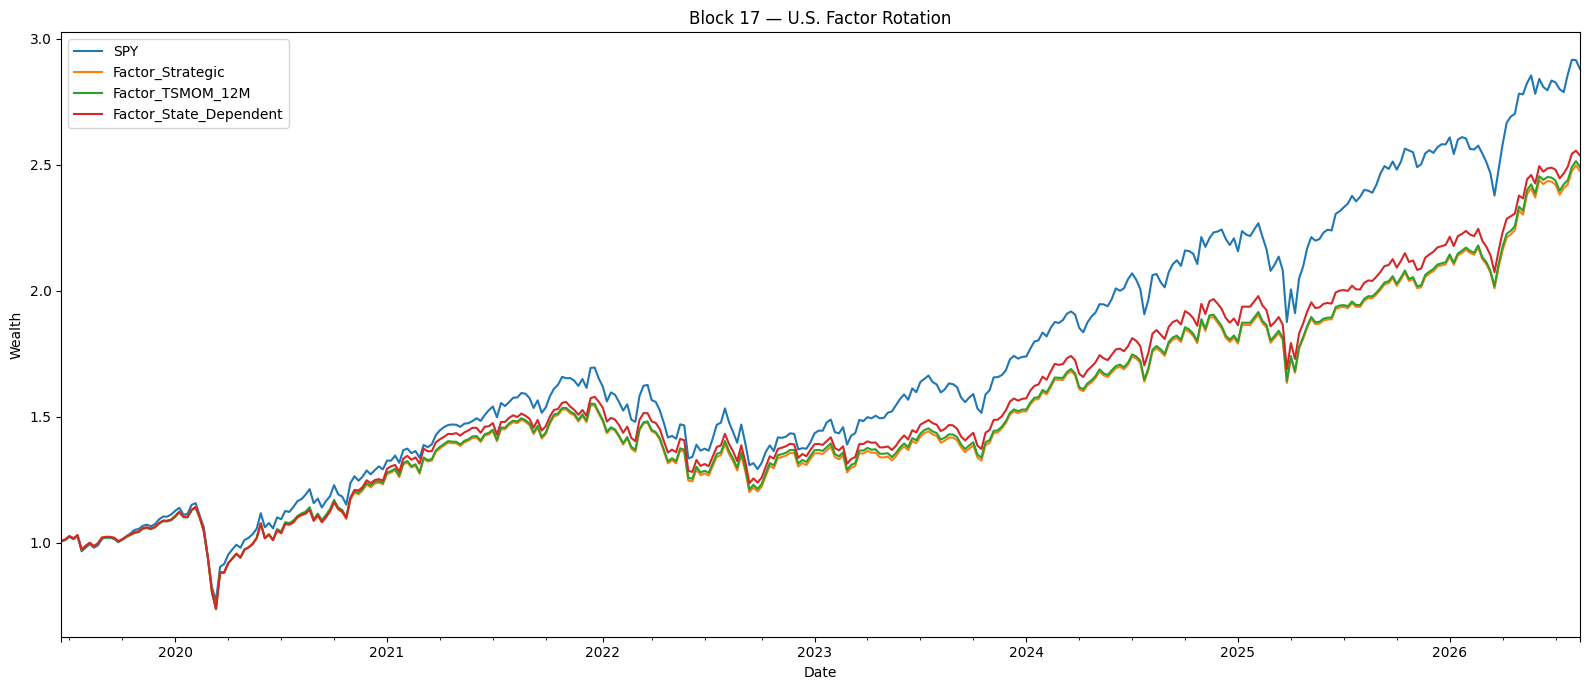

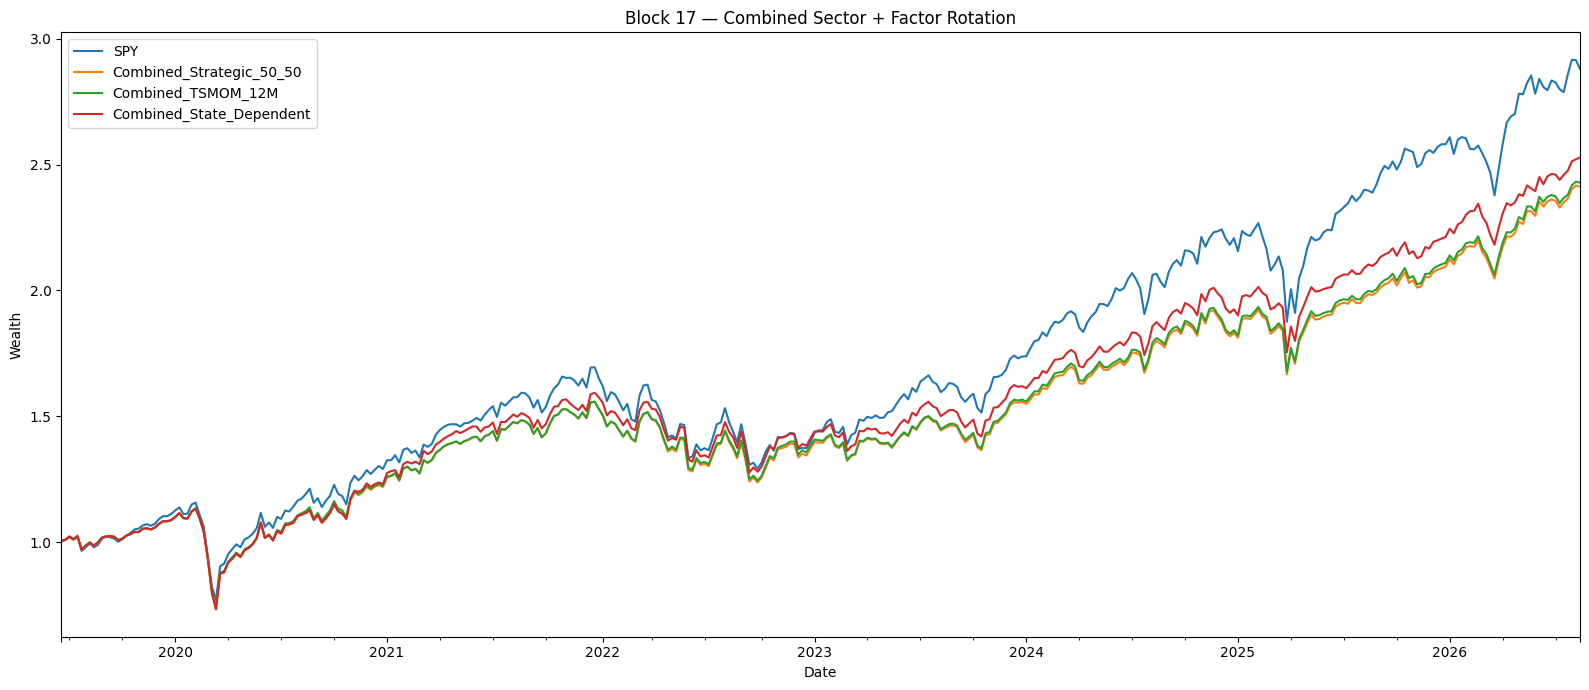

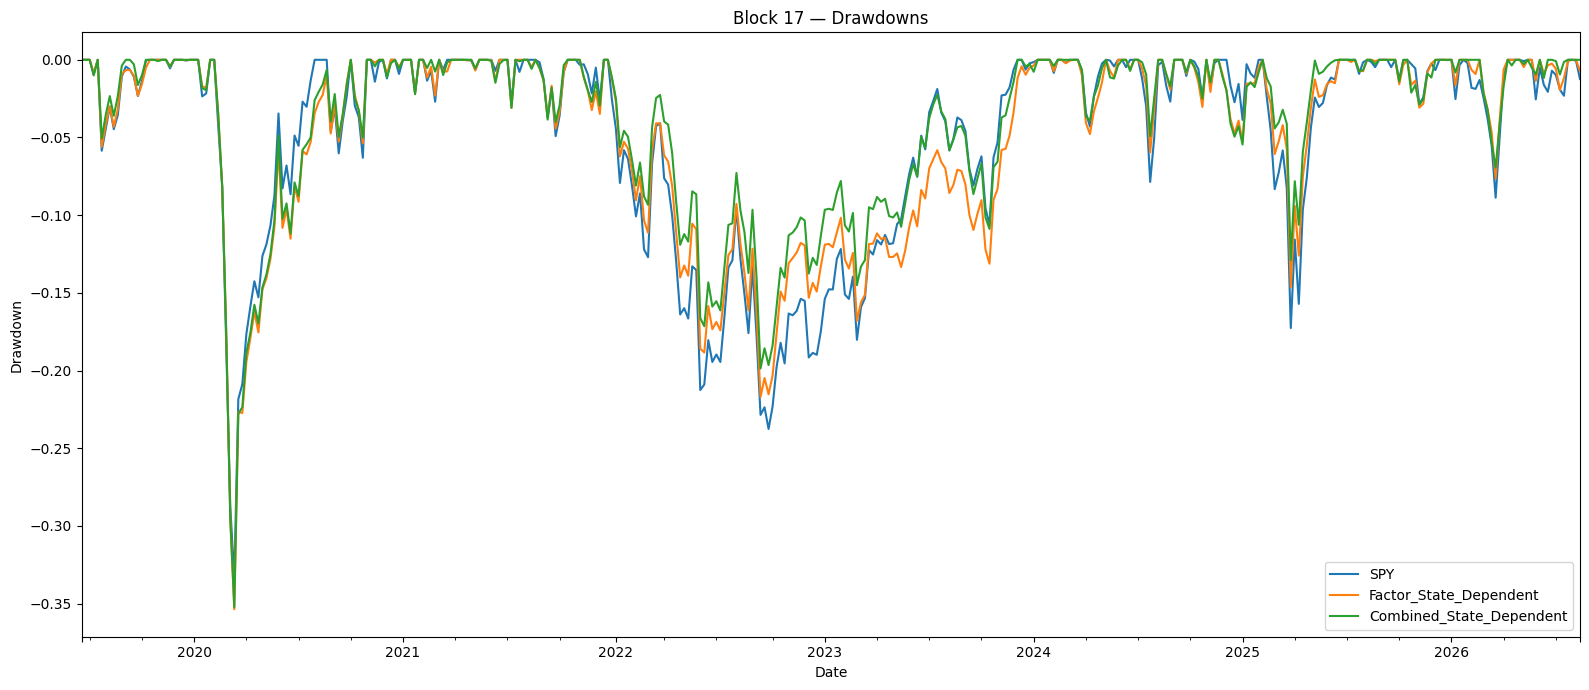

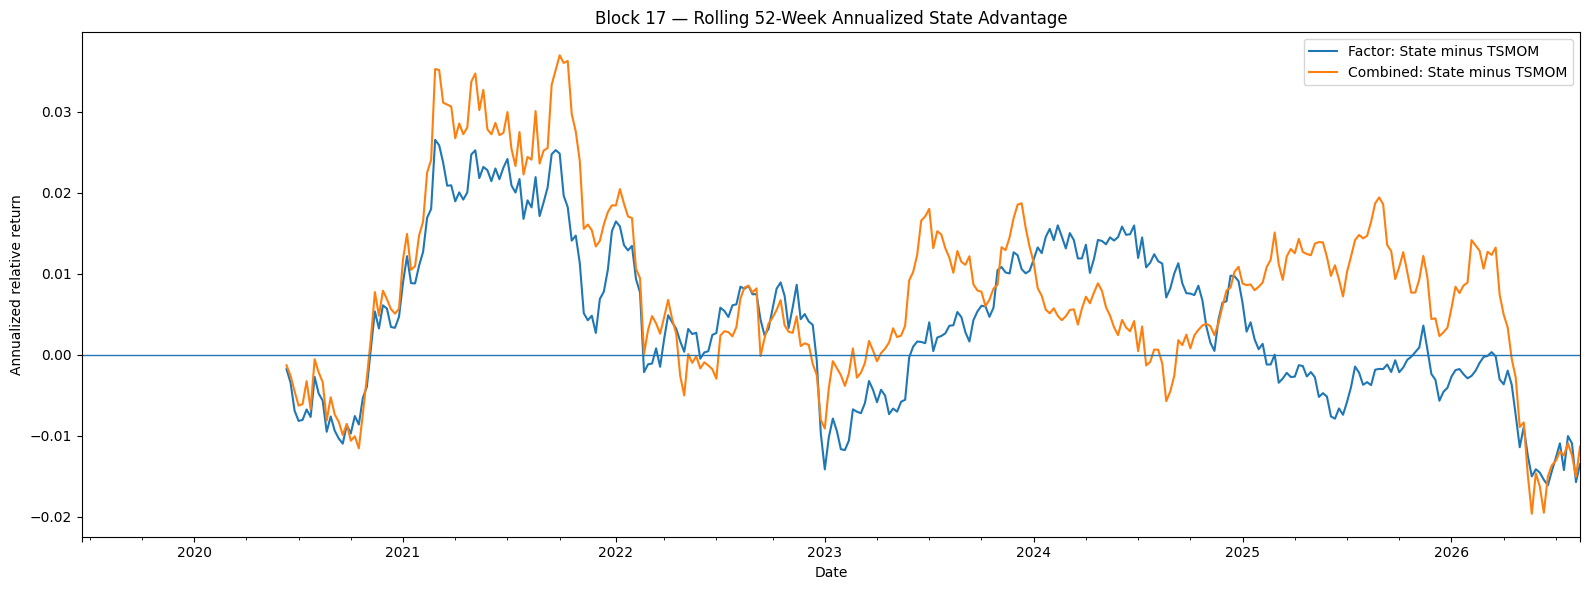

In [15]:
# ============================================================
# BLOCK 17.14 — FIGURES
# ============================================================

wealth = (1 + portfolio_returns).cumprod()

fig, ax = plt.subplots(figsize=(16, 7))
wealth[[
    "SPY",
    "Factor_Strategic",
    "Factor_TSMOM_12M",
    "Factor_State_Dependent",
]].plot(ax=ax)
ax.set_title("Block 17 — U.S. Factor Rotation")
ax.set_ylabel("Wealth")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "block_17_factor_rotation_wealth.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(16, 7))
wealth[[
    "SPY",
    "Combined_Strategic_50_50",
    "Combined_TSMOM_12M",
    "Combined_State_Dependent",
]].plot(ax=ax)
ax.set_title("Block 17 — Combined Sector + Factor Rotation")
ax.set_ylabel("Wealth")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "block_17_combined_rotation_wealth.png", dpi=180)
plt.show()

dd = wealth.div(wealth.cummax()).sub(1)
fig, ax = plt.subplots(figsize=(16, 7))
dd[[
    "SPY",
    "Factor_State_Dependent",
    "Combined_State_Dependent",
]].plot(ax=ax)
ax.set_title("Block 17 — Drawdowns")
ax.set_ylabel("Drawdown")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "block_17_drawdowns.png", dpi=180)
plt.show()

rolling_relative = (
    portfolio_returns["Factor_State_Dependent"]
    - portfolio_returns["Factor_TSMOM_12M"]
).rolling(52).mean() * 52

rolling_combined = (
    portfolio_returns["Combined_State_Dependent"]
    - portfolio_returns["Combined_TSMOM_12M"]
).rolling(52).mean() * 52

fig, ax = plt.subplots(figsize=(16, 6))
rolling_relative.plot(ax=ax, label="Factor: State minus TSMOM")
rolling_combined.plot(ax=ax, label="Combined: State minus TSMOM")
ax.axhline(0, linewidth=1)
ax.set_title("Block 17 — Rolling 52-Week Annualized State Advantage")
ax.set_ylabel("Annualized relative return")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "block_17_rolling_state_advantage.png", dpi=180)
plt.show()


In [16]:
# ============================================================
# BLOCK 17.15 — SAVE OUTPUTS & MANIFEST
# ============================================================

paths = {
    "performance": TABLE_DIR / "block_17_performance.csv",
    "net_performance_5bps": TABLE_DIR / "block_17_net_performance_5bps.csv",
    "relative_diagnostics": TABLE_DIR / "block_17_relative_diagnostics.csv",
    "factor_active_summary": TABLE_DIR / "block_17_factor_active_summary.csv",
    "portfolio_returns": OUTPUT_DIR / "block_17_weekly_portfolio_returns.parquet",
    "factor_state_long": OUTPUT_DIR / "block_17_factor_state_long.parquet",
    "factor_state_target": OUTPUT_DIR / "block_17_factor_state_target_weights.parquet",
    "factor_tsmom_target": OUTPUT_DIR / "block_17_factor_tsmom_target_weights.parquet",
    "combined_state_target": OUTPUT_DIR / "block_17_combined_state_target_weights.parquet",
    "combined_tsmom_target": OUTPUT_DIR / "block_17_combined_tsmom_target_weights.parquet",
}

performance.to_csv(paths["performance"])
net_performance_5bps.to_csv(paths["net_performance_5bps"])
relative.to_csv(paths["relative_diagnostics"], index=False)
factor_active_summary.to_csv(paths["factor_active_summary"])
portfolio_returns.to_parquet(paths["portfolio_returns"])
factor_state_long.to_parquet(paths["factor_state_long"])
factor_state_target.to_parquet(paths["factor_state_target"])
factor_tsmom_target.to_parquet(paths["factor_tsmom_target"])
combined_state_target.to_parquet(paths["combined_state_target"])
combined_tsmom_target.to_parquet(paths["combined_tsmom_target"])

manifest = {
    "block": 17,
    "title": "U.S. Equity Factor Rotation and Combined Sector–Factor Allocation",
    "research_extension": True,
    "corrected_pine_parity_implementation": True,
    "preliminary_block17_superseded": True,
    "blocks_1_to_16_altered": False,
    "signal_parameters_optimized": False,
    "frozen_block3_numerical_parity_verified": bool(signal_parity and event_parity),
    "frozen_block4_state_parity_verified": bool(state_parity),
    "frozen_block4_active_weight_parity_verified": bool(active_parity),
    "next_session_execution_timing_enforced": True,
    "leverage": False,
    "shorting": False,
    "vix_overlay": False,
    "factor_universe": {
        "MTUM": "Momentum",
        "QUAL": "Quality",
        "VLUE": "Value",
        "SIZE": "Size",
        "USMV": "Minimum Volatility",
    },
    "combined_strategic_architecture": {
        "sector_sleeve_budget": 0.50,
        "factor_sleeve_budget": 0.50,
        "within_sleeve_method": "INVERSE_VOLATILITY_52W",
    },
    "frozen_signal_parameters": PARAMS,
    "saved_files": {k: str(v) for k, v in paths.items()},
}

manifest_path = MANIFEST_DIR / "block_17_factor_and_combined_rotation.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

status = pd.DataFrame({"Value": [
    False,
    False,
    False,
    False,
    False,
    True,
    True,
    True,
    True,
    len(FACTORS),
    len(SECTORS),
    len(ALL_ASSETS),
    "50% sectors / 50% factors",
    True,
    True,
    True,
]}, index=[
    "Blocks 1–16 altered",
    "Signal parameters optimized",
    "Leverage used",
    "Shorting used",
    "VIX/correlation overlay used",
    "Frozen Block 3 numerical/event parity",
    "Frozen Block 4 state parity",
    "Frozen Block 4 active-weight parity",
    "Next-session execution timing enforced",
    "Factor ETFs",
    "Sector ETFs",
    "Combined investable ETFs",
    "Combined strategic sleeve budget",
    "Factor-only portfolio tested",
    "Combined portfolio tested",
    "All figures saved",
])

display(status)

print("\nBLOCK 17 CORRECTED COMPLETE")
print("The preliminary Block 17 is superseded.")
print("Use these outputs for the canonical factor-portability test.")


,Value
Blocks 1–16 altered,False
Signal parameters optimized,False
Leverage used,False
Shorting used,False
VIX/correlation overlay used,False
Frozen Block 3 numerical/event parity,True
Frozen Block 4 state parity,True
Frozen Block 4 active-weight parity,True
Next-session execution timing enforced,True
Factor ETFs,5



BLOCK 17 CORRECTED COMPLETE
The preliminary Block 17 is superseded.
Use these outputs for the canonical factor-portability test.
